# 0. Imports

In [174]:
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, KFold, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV # type: ignore

proj = ccrs.PlateCarree()

# 1. Data

In [49]:
DATA_DIR = "../data/"

LAT_LON = ["Lat", "Lon"]

In [84]:
#LPJ-GUESS output
lpj_df = pl.read_csv(DATA_DIR + "LPJ-GUESS_output_BERN1.csv")
lpj_df = lpj_df.rename({col: col + f"_lpj" for col in lpj_df.columns if not col in LAT_LON})
lpj_df

Lon,Lat,NPP_lpj,SoilR_lpj,MaxBiomeCmax_lpj,MaxBiomeLAI_lpj,VegC_lpj,LitterC_lpj,SoilC_lpj,Biome_Cmax_lpj,Biome_LAI_lpj,Biome_obs_lpj
f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
39.75,-1.25,0.429,0.39,0.449,1.9821,1.225,0.758,5.941,8,12,12
150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
-63.75,82.75,0.0,0.0,0.0,0.0,0.0,0.003,0.002,13,13,17
59.25,30.75,0.043,0.042,0.09,0.2146,0.127,0.084,0.543,7,11,14
24.25,27.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13,13,17
…,…,…,…,…,…,…,…,…,…,…,…
114.75,34.75,0.35,0.307,3.389,2.5025,3.502,1.763,3.537,5,5,5
12.25,52.25,0.507,0.425,6.303,3.3822,6.785,4.612,12.687,5,5,5
-154.25,61.75,0.013,0.01,0.014,0.0951,0.014,0.097,1.207,11,11,17


In [85]:
# Grid information
grid_df = pl.read_csv(DATA_DIR + "gridlist_pan_gfed_ISO3_UN_ecoregion.txt", separator=' ')
grid_df = grid_df.rename({col: col + f"_grid" for col in grid_df.columns if not col in LAT_LON})
grid_df

Lon,Lat,GFED-region_grid,Pan_2007_grid,ISO3_grid,UN_grid,Ecoregion_grid
f64,f64,i64,str,str,i64,i64
-69.75,-55.25,5,"""Americas""","""CHL""",152,4
-69.25,-55.25,5,"""Americas""","""CHL""",152,4
-71.25,-54.75,5,"""Americas""","""CHL""",152,4
-70.75,-54.75,5,"""Americas""","""CHL""",152,4
-70.25,-54.75,5,"""Americas""","""CHL""",152,4
…,…,…,…,…,…,…
-73.75,79.75,1,"""Canada""","""CAN""",124,11
-73.25,79.75,1,"""Canada""","""CAN""",124,11
-72.75,79.75,1,"""Canada""","""CAN""",124,11


In [86]:
# Soil texture
soil_df = pl.read_csv(DATA_DIR + "soilmap.dat", separator="\t")
soil_df = soil_df.drop_nans().rename({"lon": "Lon", "lat": "Lat"})
soil_df = soil_df.rename({col: col + f"_soil" for col in soil_df.columns if not col in LAT_LON})
soil_df

Lon,Lat,clay_soil,silt_soil,sand_soil,orgC_soil,CN_soil,pH_soil,cellfraction_soil
f64,f64,f64,f64,f64,f64,f64,f64,f64
-179.75,71.25,0.08,0.37,0.55,0.02,11.0,5.9,0.482
-179.75,68.75,0.2,0.48,0.32,0.031,17.0,6.3,0.753
-179.75,68.25,0.2,0.48,0.32,0.031,17.0,6.3,0.447
-179.75,67.75,0.2,0.48,0.32,0.031,17.0,6.3,0.526
-179.75,67.25,0.2,0.48,0.32,0.031,17.0,6.3,0.422
…,…,…,…,…,…,…,…,…
179.75,67.25,0.2,0.48,0.32,0.031,17.0,6.3,0.455
179.75,66.75,0.2,0.48,0.32,0.031,17.0,6.3,0.408
179.75,66.25,0.2,0.48,0.32,0.031,17.0,6.3,0.597


In [87]:
# Load all climate datafiles and put in one dictionary
climate_files = {
    "tswrf": "Tswrfdaymean1961_1990.csv",
    "pre": "Predaymean1961_1990.csv",
    "tmp": "Tmpdaymean1961_1990.csv",
    "tmax": "Tmaxdaymean1961_1990.csv",
    "tmin": "Tmindaymean1961_1990.csv"
}

climate_df = {}
for name, path in climate_files.items():
    df = pl.read_csv(DATA_DIR + path)
    df = df.rename({col: col + f"_{name}" for col in df.columns if not col in LAT_LON})
    climate_df[name] = df

# Load all climate statistics datafiles and put in one dictionary
stats_files = {
    "tswrf": "Tswrfdaymean1961_1990_stats.csv",
    "pre": "Predaymean1961_1990_stats.csv",
    "tmp": "Tmpdaymean1961_1990_stats.csv",
    "tmax": "Tmaxdaymean1961_1990_stats.csv",
    "tmin": "Tmindaymean1961_1990_stats.csv"}

stats_df = {}
for name, path in stats_files.items():
    df = pl.read_csv(DATA_DIR + path)
    df = df.rename({col: col + f"_{name}" for col in df.columns if not col in LAT_LON})
    stats_df[name] = df

## 1.1 Merge dataframes

In [122]:
# Merge all dataframes on Lat and Lon
merged_df = lpj_df.join(grid_df, on=LAT_LON, how="inner").join(soil_df, on=LAT_LON, how="inner")

for name, df in stats_df.items():
    merged_df = merged_df.join(df, on=LAT_LON, how="inner")

In [123]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open(DATA_DIR + "legend of biomes.txt", 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]
biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [124]:
def drop_ground_truth(df):
    """Drops Lat, Lon, and all columns that end with '_lpj' or '_grid' from the dataframe."""
    return df.select([col for col in df.columns if not col.endswith(("_lpj", "_grid")) and col not in ["Lat", "Lon"]])

def drop_columns(df, str_in_columns_to_drop, keep_columns=[]):
    """Drops columns containing a specified string, except specified columns."""
    # Drop columns containing the specified string, except for those in keep_columns
    return df.select([col for col in df.columns if str_in_columns_to_drop not in col or col in keep_columns])



    

# 2. Data Description and Visualization
In this phase, provide an overview of the distribution of the outcome variables and select a
few key features for visualization. Present these insights using graphical representations
and a summary table of measures. You can refer to the RandomForestDemo notebook for
inspiration.

# 3. Binary Classification
In this part, you are going to build a binary classifier to classify two classes of biomes from
“Biome_obs”. You can choose one of the biomes and try to train a classifier that can distin-
guish this biome from the other data, e.g, ’Arctic/alpine tundra’ or ’not Arctic/alpine tundra’.
One way to narrow down the data if you have trouble creating the binary classifier is to
only include samples from two different country codes or regions.

In [125]:
arctic_str = "Arctic/alpine tundra"
arctic_index = biome_names.index(arctic_str) + 1

canada_df = merged_df.filter(pl.col("ISO3_grid") == "CAN")
russia_df = merged_df.filter(pl.col("ISO3_grid") == "RUS")

#### 3.1 Data Split
Split your dataset into two parts: a training set and a test set. The training set is used to
train the model, and the test set is used to evaluate model performance. Think through
how you split your data and what fits your purpose. Ways to split your data could be
through climate, zone, biome, countries or continents. Are all the biomes represented in
both your train and test data? Are the frequency of biome classes representative?

In [126]:
y_train = canada_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32) == arctic_index).to_numpy().flatten()
X_train = drop_ground_truth(canada_df) # Removes Lat, Lon, and all columns that end with '_lpj' or '_grid' from the dataframe

y_test = russia_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32) == arctic_index).to_numpy().flatten()
X_test = drop_ground_truth(russia_df)

#### 3.2. Model training
Next, train a Random Forest binary classification model. You can start by using training
data from one smaller region (could be one country code). Evaluate your model and try to
optimise the hyperparameters.

In [127]:
bin_class = RandomForestClassifier(random_state=1, max_depth=5, n_estimators=100) 
bin_class.fit(X_train, y_train) # Train the model on the training data

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

#### 3.3. Model evaluation
Evaluate the model's performance using appropriate metrics for binary classification. Common metrics include precision, recall, and to plot the predictions in a confusion matrix. Test
the model trained on one part of the world on the same biome in another part of the world,
e.g., Arctic/alpine tundra in either North America or Siberia. Does the model show equal
skill in both areas? Could the features you have chosen affect the skill of the model in another part of the world? Why?

In [128]:
score_train = bin_class.score(X_train, y_train)
score_test = bin_class.score(X_test, y_test)
print(f"Training score: {score_train:.4f}")
print(f"Test score: {score_test:.4f}")

Training score: 0.9718
Test score: 0.8419


The scores above represents accuracy

In [129]:
print("\nClassification Report:")
print(classification_report(y_test, bin_class.predict(X_test), target_names=["Not Arctic", "Arctic"]))


Classification Report:
              precision    recall  f1-score   support

  Not Arctic       0.93      0.82      0.87      7810
      Arctic       0.71      0.88      0.79      3886

    accuracy                           0.84     11696
   macro avg       0.82      0.85      0.83     11696
weighted avg       0.86      0.84      0.85     11696



The score that was suggested to use in the lecture was F1. This is a combined measure of precision and recall.

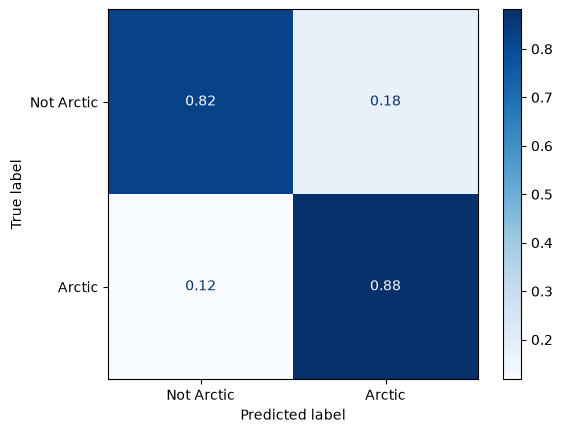

In [130]:
ConfusionMatrixDisplay.from_estimator(
    bin_class, X_test, y_test, display_labels=['Not Arctic', 'Arctic'], cmap=plt.cm.Blues, normalize='true')
plt.show()

#### 3.4. Feature importance and model interpretation
Analyze which features played the most crucial role in your model's decisions. Finally, discuss and interpret your results comprehensively, and explore any misclassifications to gain
valuable insights into how well machine learning models adapt to different continents and
environments. Are all features that you used for training necessary? Could you reduce the
number of features used? Were there features that you did not use that could be important? Why would they be important?

Optional: Plot the misclassified regions on a world map.

In [131]:
feature_imp = pd.DataFrame(
    {'importance':bin_class.feature_importances_},
    index=X_train.columns)
feature_imp = feature_imp.sort_values(by='importance', ascending=False)
print("\nFeature Importances:")
print(feature_imp.head(60))


Feature Importances:
                    importance
FallMedian_tmp        0.104522
FallMedian_tmax       0.069129
FallMean_tmp          0.068299
SummerMedian_tmin     0.068095
FallMean_tmax         0.057013
SummerMedian_tmax     0.050376
SummerMean_tmin       0.048441
FallMean_tmin         0.039333
SummerMedian_tmp      0.037711
SpringStd_tmin        0.035169
SummerMean_tmax       0.033424
FallMean_tswrf        0.030777
SpringStd_tmp         0.027818
SummerMean_tmp        0.026613
SummerMean_tswrf      0.023701
SpringStd_tmax        0.019603
FallMedian_tmin       0.017840
SpringMedian_tswrf    0.015997
SpringMean_tmin       0.015910
FallMedian_tswrf      0.015532
WinterMean_tmin       0.015149
WinterMean_tmax       0.014811
WinterMedian_tswrf    0.013186
WinterMedian_tmin     0.012420
WinterMean_tmp        0.011762
SpringMean_tmp        0.010808
WinterMedian_tmax     0.010064
SummerStd_tmp         0.007598
WinterStd_tmax        0.007129
WinterStd_tswrf       0.006831
SummerMedian_tswr

## Reduce features and fit new models

After looking at the heat correlation map of means and medians for the temperature in diferent seasons, we choose to remove the columns with medians before creating the model. They do not add any information. 

In [132]:
# Remake the model without all features that have the work "median" in their name, as they are highly correlated with the mean features
X_train_red = drop_columns(X_train, "Median") # removes all columns that have the word "median" in their name
X_test_red = drop_columns(X_test, "Median")

# Make a new model with the reduced feature set
bin_class2 = RandomForestClassifier(random_state=1, max_depth=5, n_estimators=100) 
bin_class2.fit(X_train_red, y_train) # Train the model on the training data

score_train2 = bin_class2.score(X_train_red, y_train)
score_test2 = bin_class2.score(X_test_red, y_test)
print(f"Training score (all features): {score_train:.4f}")
print(f"Test score (all features): {score_test:.4f}\n")

print(f"Training score (no median features): {score_train2:.4f}")
print(f"Test score (no median features): {score_test2:.4f}")

# Print classification report for the model without median features
print("\nClassification Report (no median features):")
print(classification_report(y_test, bin_class2.predict(X_test_red), target_names=["Not Arctic", "Arctic"]))

# Print feature importances for the model without median features
feature_imp2 = pd.DataFrame(
    {'importance':bin_class2.feature_importances_},
    index=X_train_red.columns)
feature_imp2 = feature_imp2.sort_values(by='importance', ascending=False)
print("\nFeature Importances (no median features):")
print(feature_imp2.head(60))

Training score (all features): 0.9718
Test score (all features): 0.8419

Training score (no median features): 0.9708
Test score (no median features): 0.8483

Classification Report (no median features):
              precision    recall  f1-score   support

  Not Arctic       0.94      0.83      0.88      7810
      Arctic       0.72      0.89      0.80      3886

    accuracy                           0.85     11696
   macro avg       0.83      0.86      0.84     11696
weighted avg       0.87      0.85      0.85     11696


Feature Importances (no median features):
                   importance
FallMean_tmp         0.128994
SummerMean_tmin      0.100507
FallMean_tmax        0.097730
SummerMean_tmax      0.088246
SummerMean_tmp       0.068579
FallMean_tmin        0.065040
SpringStd_tmp        0.045504
FallMean_tswrf       0.035994
SpringStd_tmin       0.035174
SummerMean_tswrf     0.032106
WinterMean_tmax      0.027457
WinterMean_tmin      0.026216
SpringStd_tmax       0.026144
SpringMe

Next, I will try to drop all soil columns that are below 0.0015 in feature importance. And make a new binary model from this.

In [147]:
# Drop unwanted soil features (everything except ph_soil)
X_train_red = drop_columns(X_train_red, str_in_columns_to_drop="soil", keep_columns=["pH_soil"]) # removes all unwanted soil features
X_test_red = drop_columns(X_test_red, str_in_columns_to_drop="soil", keep_columns=["pH_soil"])

# Make a new model with the reduced feature set
bin_class3 = RandomForestClassifier(random_state=1, max_depth=5, n_estimators=100) 
bin_class3.fit(X_train_red, y_train) # Train the model on the training data

score_train3 = bin_class3.score(X_train_red, y_train)
score_test3 = bin_class3.score(X_test_red, y_test)

print(f"Training score (median and soil features removed): {score_train3:.4f}")
print(f"Test score (median and soil features removed): {score_test3:.4f}")

# Print classification report for the model without median features
print("\nClassification Report (median and soil features removed):")
print(classification_report(y_test, bin_class3.predict(X_test_red), target_names=["Not Arctic", "Arctic"]))

# Print feature importances for the model without median features
feature_imp3 = pd.DataFrame(
    {'importance':bin_class3.feature_importances_},
    index=X_train_red.columns)
feature_imp3 = feature_imp3.sort_values(by='importance', ascending=False)
print("\nFeature Importances (median and soil features removed):")
print(feature_imp3.head(60))

Training score (median and soil features removed): 0.9701
Test score (median and soil features removed): 0.8608

Classification Report (median and soil features removed):
              precision    recall  f1-score   support

  Not Arctic       0.94      0.84      0.89      7810
      Arctic       0.74      0.89      0.81      3886

    accuracy                           0.86     11696
   macro avg       0.84      0.87      0.85     11696
weighted avg       0.87      0.86      0.86     11696


Feature Importances (median and soil features removed):
                  importance
FallMean_tmp        0.130234
FallMean_tmax       0.117149
SummerMean_tmin     0.091790
SummerMean_tmax     0.068612
SpringStd_tmin      0.060552
FallMean_tmin       0.056021
FallMean_tswrf      0.051189
SummerMean_tmp      0.040077
SummerMean_tswrf    0.039420
WinterMean_tmin     0.034364
SpringStd_tmp       0.032453
WinterMean_tmax     0.031170
SpringStd_tmax      0.021039
SpringMean_tmin     0.019407
WinterMean

This looks better. Will not try to improve this for now.

## Make plots

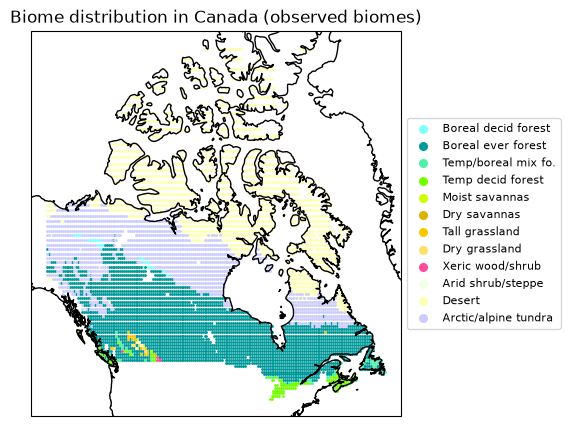

In [134]:
canada_mean_lon = canada_df.select(pl.col("Lon")).mean().item()
proj_canada = ccrs.Mercator(central_longitude=canada_mean_lon)

# Biome IDs that are actually present in Canada
present_biomes = (canada_df.select("Biome_obs_lpj").unique().sort("Biome_obs_lpj").to_series().to_list())

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": proj_canada})

for biome_id in present_biomes:
    i = biome_id - 1
    name = biome_names[i]
    biome = canada_df.filter(pl.col("Biome_obs_lpj") == biome_id)

    ax.scatter(
        biome["Lon"].to_numpy(),
        biome["Lat"].to_numpy(),
        color=biome_rgbs[i],
        s=1,                 # Control the size of the dots in the plot
        label=name,
        transform=proj
    )

ax.coastlines()
legend = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
for handle in legend.legend_handles:
    handle.set_sizes([30]) # control the size of the dots in the legend

plt.title("Biome distribution in Canada (observed biomes)")
plt.show()

In [135]:
russia_mean_lon = russia_df.select(pl.col("Lon")).mean().item()
proj_russia = ccrs.Mercator(central_longitude=russia_mean_lon)

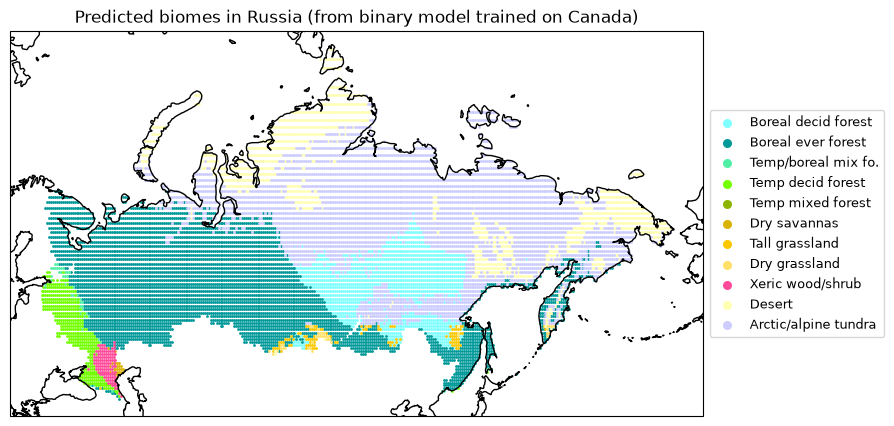

In [150]:
present_biomes = russia_df.select("Biome_obs_lpj").unique().sort("Biome_obs_lpj").to_series().to_list()

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_russia))

for biome_id in present_biomes:
    i = biome_id - 1
    name = biome_names[i]
    biome = russia_df.filter(pl.col("Biome_obs_lpj") == biome_id)
    ax.scatter(biome["Lon"].to_numpy(), 
    biome["Lat"].to_numpy(), 
    color=biome_rgbs[i], s=1, 
    label=name, transform=proj)

ax.coastlines()

legend = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)

for handle in legend.legend_handles:
    handle.set_sizes([30])

plt.title("Predicted biomes in Russia (from binary model trained on Canada)")
plt.show()

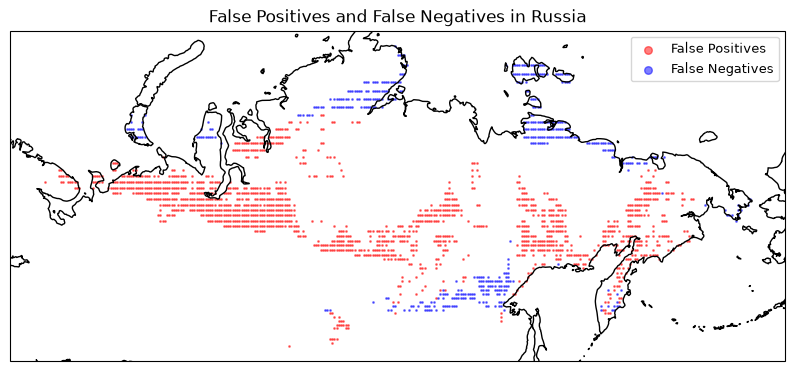

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_russia))

y_pred = bin_class.predict(X_test)
fp = (y_pred == 1) & (y_test == 0)
fn = (y_pred == 0) & (y_test == 1)
fp_df = russia_df.filter(fp)
fn_df = russia_df.filter(fn)

ax.scatter(fp_df["Lon"].to_numpy(), fp_df["Lat"].to_numpy(), color="red", 
s=1, alpha=0.5, transform=proj, label="False Positives")
ax.scatter(fn_df["Lon"].to_numpy(), fn_df["Lat"].to_numpy(), color="blue", 
s=1, alpha=0.5, transform=proj, label="False Negatives")

ax.coastlines()

legend = ax.legend(fontsize=9)
for handle in legend.legend_handles:
    handle.set_sizes([30])

plt.title("False Positives and False Negatives in Russia")
plt.show()

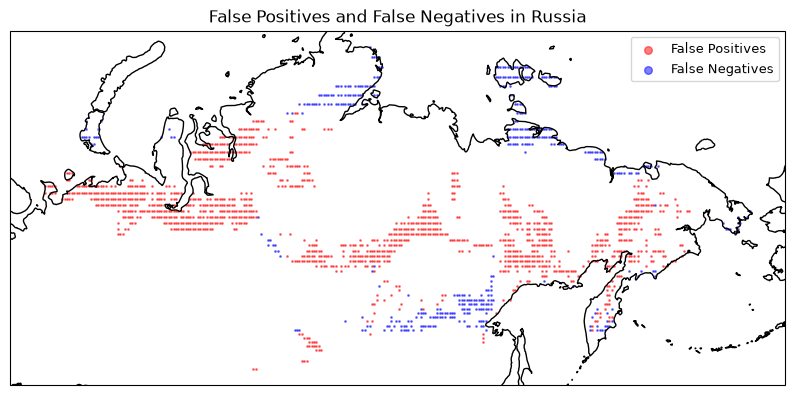

In [149]:
# Remake the same plot, but with the model that has median and soil features removed
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj_russia))

X_test3 = X_test[bin_class3.feature_names_in_] # Select only the features that were used in the model with median and soil features removed

y_pred3 = bin_class3.predict(X_test3)
fp = (y_pred3 == 1) & (y_test == 0)
fn = (y_pred3 == 0) & (y_test == 1)
fp_df = russia_df.filter(fp)
fn_df = russia_df.filter(fn)

ax.scatter(fp_df["Lon"].to_numpy(), fp_df["Lat"].to_numpy(), color="red", 
s=1, alpha=0.5, transform=proj, label="False Positives")
ax.scatter(fn_df["Lon"].to_numpy(), fn_df["Lat"].to_numpy(), color="blue", 
s=1, alpha=0.5, transform=proj, label="False Negatives")

ax.coastlines()

legend = ax.legend(fontsize=9)
for handle in legend.legend_handles:
    handle.set_sizes([30])

plt.title("False Positives and False Negatives in Russia")
plt.show()

# 4. Multiclass classification
In this part, you are going to build two multiclass random forest classification models to
classify up to 18 biomes. You can use a combination of country code and region to build a
subset that you as a group would be interested in, e.g. South America, Europe, South-east
Asia et.c., again try to find another region where an interesting comparison can be made
and if your model are performing well on a different geographic region. For example boreal
Europe vs Canada, mainland USA (not including Alaska) vs. Australia or South America
vs. Africa. Important: Use “Biome_obs” as your target variable.

#### 4.1 Data split
Split your dataset into two parts: a training set, and a test set. The training set is used to
train the model, the validation set to tune hyperparameters, and the test set to evaluate
model performance.

In [168]:
# Make new df with only european countries
europe_df = merged_df.filter(pl.col("ISO3_grid").is_in([
    "AUT", "BEL", "BGR", "HRV", "CYP", "CZE", "DNK", "EST", "FIN", "FRA", "DEU", "GRC", 
    "HUN", "ISL", "IRL", "ITA", "LVA", "LTU", "LUX", "MLT", "NLD", "POL", "PRT", "ROU", 
    "SVK", "SVN", "ESP", "SWE", "GBR"]))
    
# Remove biome 13 (Mediterranean forest, woodland, and scrub) from the dataset, 
# as it only has one observation in the dataset, which is not enough to train a model on
europe_df = europe_df.filter(pl.col("Biome_obs_lpj") != 13) 

# extract Biome_obs_lpj as y_train for europe_df
X = drop_ground_truth(europe_df)
y = europe_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32)).to_numpy().flatten()

# split europe_df into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) # with stratify=y to ensure that the class distribution is similar in both train and test sets


#### 4.2 Model training
Next, train a Random Forest classification model using training data, and then put the
model on the test data.

In [170]:
# Train a baseline model with default hyperparameters
multi_class = RandomForestClassifier(random_state=1)
multi_class.fit(X_train, y_train.flatten())

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [172]:
# evaluate the model on the test set
score_train = multi_class.score(X_train, y_train.flatten())
score_test = multi_class.score(X_test, y_test.flatten())
print(f"Training score: {score_train:.4f}")
print(f"Test score: {score_test:.4f}")

Training score: 1.0000
Test score: 0.8223


In [154]:
print("\nClassification Report:")
target_names = [biome_names[i-1] for i in set(y_test.to_numpy().flatten())]
print(classification_report(y_test, multi_class.predict(X_test), target_names=target_names))


Classification Report:
                      precision    recall  f1-score   support

 Boreal decid forest       0.87      0.45      0.59      1338
  Boreal ever forest       0.76      0.84      0.80      5998
 Temp/boreal mix fo.       0.40      0.13      0.20       455
   Temp decid forest       0.81      0.74      0.77      2397
 Temp broad ever fo.       0.86      0.74      0.80      1377
   Temp mixed forest       0.57      0.07      0.13        54
  Trop season forest       0.49      0.58      0.53      1414
    Trop rain forest       0.82      0.90      0.86      2566
   Trop decid forest       0.58      0.39      0.47      1066
      Moist savannas       0.16      0.53      0.24       437
        Dry savannas       0.27      0.43      0.33      1678
      Tall grassland       0.00      0.00      0.00       210
       Dry grassland       0.43      0.21      0.28      1829
    Xeric wood/shrub       0.36      0.40      0.38      1223
   Arid shrub/steppe       0.55      0.28    

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## 4.3 Hyper-parameter Tuning
Use cross-validation to tune hyperparameters like the number of trees, tree depth, and
minimum leaf samples. This step can help improve model performance. If you encounter
issues with runtime, consider narrowing your focus to fewer geographic regions. It is also
possible to sample the grid list with the .sample() function on Pandas DataFrames, in that
case, make sure to sample only the training dataset and not the full dataset.

In [175]:
# Define parameters to test in the grid search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
rf = RandomForestClassifier(random_state=1, n_jobs=-1)

# Run grid search to find the best hyperparameters
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 50}
Best CV accuracy: 0.8356


In [ ]:
# Train a new model with the best hyperparameters found in the grid search
multi_class_tuned = grid_search.best_estimator_
print(f"Training accuracy: {multi_class_tuned.score(X_train, y_train):.4f}")
print(f"Test accuracy: {multi_class_tuned.score(X_test, y_test):.4f}")

Training accuracy: 0.9586
Test accuracy: 0.8244


## 4.4. Model Evaluation
Evaluate the model's performance using appropriate metrics for multiclass classification.



## 4.5. Features Importance
Analyze which features played the most crucial role in your model's decisions. What happens when you are limiting the number of features? Also, are there any auto-correlations
in the feature data?

In [192]:
# Print feature importances for the tuned multi-class model
feature_imp_tuned = pd.DataFrame(
    {'importance':multi_class_tuned.feature_importances_},
    index=X_train.columns)
feature_imp_tuned = feature_imp_tuned.sort_values(by='importance', ascending=False) 

print("\nFeature Importances (tuned multi-class model):")
print(feature_imp_tuned.head(60))


Feature Importances (tuned multi-class model):
                    importance
SummerMean_tmin       0.051240
FallMean_tmp          0.045665
WinterMean_tmp        0.044329
FallMean_tmin         0.040536
SpringMean_tmp        0.038252
WinterMedian_tmp      0.037117
SummerMedian_tmp      0.036703
SummerMean_tmp        0.035073
SummerMean_tmax       0.032540
WinterMean_tswrf      0.032488
SpringMean_tswrf      0.029703
WinterMean_tmax       0.028499
FallMedian_tmp        0.028319
SummerMedian_tmin     0.026156
SpringMedian_tmp      0.025932
FallMean_tmax         0.025636
SummerMedian_tmax     0.024671
SpringMean_tmax       0.020725
WinterMedian_tmin     0.018750
FallMedian_tmin       0.018528
FallMedian_tmax       0.018453
WinterMean_tmin       0.017040
WinterMedian_tmax     0.015349
SpringMedian_tmax     0.013692
SpringMedian_tswrf    0.012424
WinterMedian_tswrf    0.011830
FallStd_pre           0.011636
FallMedian_pre        0.011560
FallMean_pre          0.010948
WinterStd_tmin        

In [194]:
[f for f in X_train.columns if "soil" in f] # are there any soil features in the model? 

feature_importance = pd.Series(multi_class_tuned.feature_importances_, index=X_train.columns)
print(feature_importance[feature_importance.index.str.contains("soil")].sort_values(ascending=False))

sand_soil            0.004045
cellfraction_soil    0.003858
pH_soil              0.002511
clay_soil            0.002510
orgC_soil            0.002137
silt_soil            0.001743
CN_soil              0.001652
dtype: float64


These soil features have too small feature importance to be shown in the longer list above. Candidates to remove when improving the model. Also try to remove the medians as in the previous binary model. 

## Make plots

<Figure size 1000x1000 with 0 Axes>

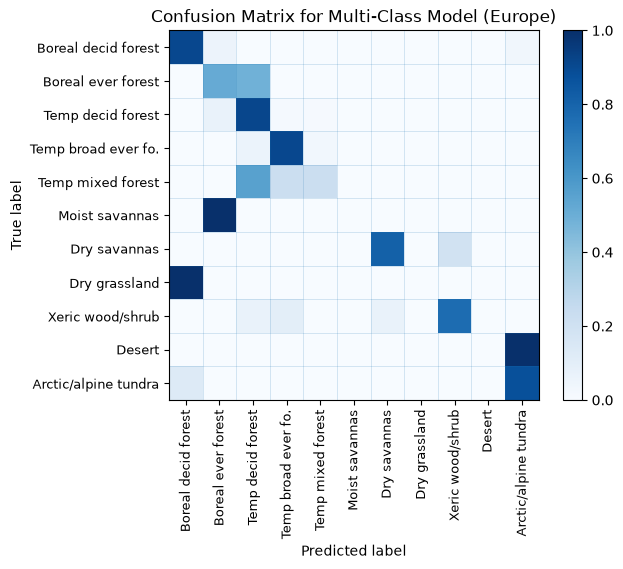

In [190]:
# Get the target names for the classes in the model
model_target_names = [target_names[i - 2] for i in multi_class.classes_]

# Make confusion matrix for the tuned multi-class model
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay.from_estimator(
    multi_class, X_test, y_test, display_labels=model_target_names, 
    cmap=plt.cm.Blues, normalize="true", include_values=False)
disp.ax_.tick_params(axis="both", labelsize=9)
for i in range(len(model_target_names) + 1):
    disp.ax_.axvline(i - 0.5, linewidth=0.4, alpha=0.3)
    disp.ax_.axhline(i - 0.5, linewidth=0.4, alpha=0.3)
plt.xticks(rotation=90)
disp.ax_.set_title("Confusion Matrix for Multi-Class Model (Europe)", fontsize=12)
plt.show()

<Figure size 1000x1000 with 0 Axes>

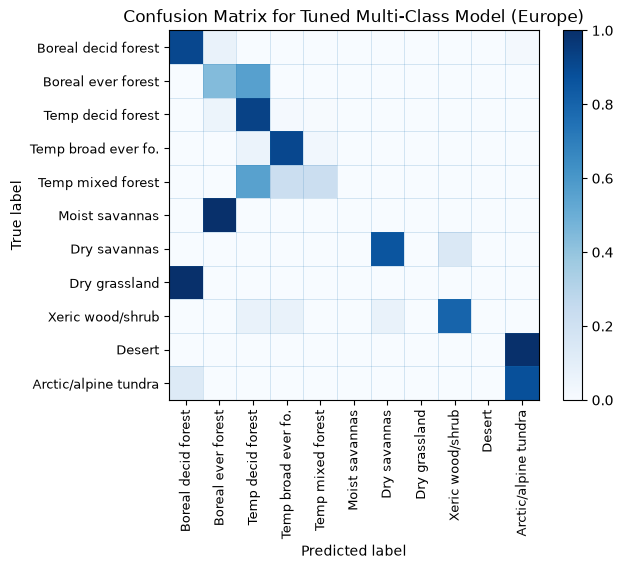

In [187]:
# Get the target names for the classes in the model
model_target_names = [target_names[i - 2] for i in multi_class_tuned.classes_]

# Make confusion matrix for the tuned multi-class model
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay.from_estimator(
    multi_class_tuned, X_test, y_test, display_labels=model_target_names, 
    cmap=plt.cm.Blues, normalize="true", include_values=False)
disp.ax_.tick_params(axis="both", labelsize=9)
for i in range(len(model_target_names) + 1):
    disp.ax_.axvline(i - 0.5, linewidth=0.4, alpha=0.3)
    disp.ax_.axhline(i - 0.5, linewidth=0.4, alpha=0.3)
plt.xticks(rotation=90)
disp.ax_.set_title("Confusion Matrix for Tuned Multi-Class Model (Europe)", fontsize=12)
plt.show()


Comment: Some of the diagonal boxes are very light. This indicates that the model has low recall for that biome, i.e. it was bad at predicting that biome correctly. Could depend on few observations for that biome or that it is hard to distinguish from other biomes. 

It seems like tall grassland is predicted as boreal ever forest or arctic tundra.

## 4.6. Compare LPJ-GUESS model and machine learning model
Compare your trained against the biomes estimated by LPJ-GUESS for “Biome_Cmax”
and Biome_LAI. Discuss the difference in prediction between the LPJ-GUESS outputs and
the machine learning model outputs. Where do the models agree and where do the model
predictions diverge? Why?